In [9]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np

# Define the column names
# The first column is subject ID, the last is the class label (0 or 1)
# Features are numbered 1 through 26 in between
column_names = ['subject_id'] + [f'feature_{i}' for i in range(1, 27)] + ['class_label']

# Load the dataset from the provided file path
# Make sure 'train_data.txt' is in your Colab environment
try:
    df = pd.read_csv('train_data.txt', header=None, names=column_names)
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: 'train_data.txt' not found. Please upload the file.")

# Display the first few rows and basic info
print("\nDataset Shape:", df.shape)
print("\nFirst 5 Rows:")
display(df.head())
print("\nDataset Info:")
df.info()

Saving train_data.txt to train_data (1).txt
Dataset loaded successfully!

Dataset Shape: (1040, 28)

First 5 Rows:


,subject_id,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,class_label
1,1.488,0.000090,0.900,0.794,2.699,8.334,0.779,4.517,4.609,6.802,...,187.576,160,159,0.006065,0.000416,0.000,0,0.000,23,1
1,0.728,0.000038,0.353,0.376,1.059,5.864,0.642,2.058,3.180,7.194,...,234.505,170,169,0.005181,0.000403,2.247,0,0.000,23,1
1,1.220,0.000074,0.732,0.670,2.196,8.719,0.875,4.347,5.166,7.548,...,211.442,1431,1427,0.006071,0.000474,10.656,1,0.178,23,1
1,2.502,0.000123,1.156,1.634,3.469,13.513,1.273,5.263,8.771,16.779,...,220.230,94,92,0.004910,0.000320,0.000,0,0.000,23,1
1,3.509,0.000167,1.715,1.539,5.145,9.112,1.040,3.102,4.927,12.823,...,225.162,117,114,0.004757,0.000380,18.182,1,13.318,23,1



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 1040 entries, 1 to 40
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   subject_id   1040 non-null   float64
 1   feature_1    1040 non-null   float64
 2   feature_2    1040 non-null   float64
 3   feature_3    1040 non-null   float64
 4   feature_4    1040 non-null   float64
 5   feature_5    1040 non-null   float64
 6   feature_6    1040 non-null   float64
 7   feature_7    1040 non-null   float64
 8   feature_8    1040 non-null   float64
 9   feature_9    1040 non-null   float64
 10  feature_10   1040 non-null   float64
 11  feature_11   1040 non-null   float64
 12  feature_12   1040 non-null   float64
 13  feature_13   1040 non-null   float64
 14  feature_14   1040 non-null   float64
 15  feature_15   1040 non-null   float64
 16  feature_16   1040 non-null   float64
 17  feature_17   1040 non-null   float64
 18  feature_18   1040 non-null   float64
 19

In [3]:
# Group by subject_id and aggregate the features
# For features, we take the mean
# For the class label, it's the same for each subject, so we take the 'first' value
aggregation_rules = {f'feature_{i}': 'mean' for i in range(1, 27)}
aggregation_rules['class_label'] = 'first'

subject_df = df.groupby('subject_id').agg(aggregation_rules).reset_index()

print("Aggregation complete!")
print("\nNew Subject-Level Dataset Shape:", subject_df.shape)
print("\nFirst 5 Rows of the Aggregated Dataset:")
display(subject_df.head())

Aggregation complete!

New Subject-Level Dataset Shape: (944, 28)

First 5 Rows of the Aggregated Dataset:


,subject_id,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,class_label
0,0.190,0.000006,0.088,0.081,0.265,1.185,0.103,0.496,0.708,1.282,...,305.625,310.0,309.0,0.003412,0.000066,0.000,0.0,0.00,1.0,0
1,0.195,0.000010,0.098,0.112,0.295,3.254,0.298,1.563,1.935,2.721,...,208.130,1062.0,1061.0,0.005122,0.000116,0.000,0.0,0.00,5.0,1
2,0.208,0.000009,0.084,0.097,0.252,2.720,0.239,1.552,1.663,2.025,...,234.903,162.0,161.0,0.004444,0.000129,0.000,0.0,0.00,1.0,0
3,0.209,0.000008,0.107,0.116,0.322,1.555,0.142,0.762,0.927,1.252,...,275.238,551.0,550.0,0.003702,0.000064,0.000,0.0,0.00,1.0,0
4,0.253,0.000015,0.118,0.129,0.353,2.472,0.235,1.346,1.626,1.968,...,346.587,670.0,668.0,0.005995,0.000534,5.374,1.0,0.59,1.0,0


In [4]:
import pandas as pd

try:
    demographics_df = pd.read_csv('demographics.csv', encoding='latin1')

    # --- ROBUST FIX ---
    # Instead of assuming the column name is 'Group', we'll get the name of the second column by its position (index 1).
    # This is more reliable if the header name is inconsistent.
    group_column_name = demographics_df.columns[1]
    print(f"Found group information in column named: '{group_column_name}'")

    # Now, use the actual column name to create the class_label
    demographics_df['class_label'] = demographics_df[group_column_name].apply(lambda x: 0 if x == 1 else 1)

    print("\nDemographics data processed successfully!")
    display(demographics_df.head())

except Exception as e:
    print(f"An error occurred: {e}")

An error occurred: [Errno 2] No such file or directory: 'demographics.csv'


In [6]:
# Define column names based on format.txt
columns = [
    'L_Total', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6', 'L7', 'L8',
    'R_Total', 'R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8'
]

# Load a sample file for a control subject
try:
    sample_gait_df = pd.read_csv('GaCo01_01.txt', sep='\t', header=None, names=columns)

    # Plot the total force for each foot over time
    plt.figure(figsize=(15, 5))
    plt.plot(sample_gait_df.index / 100, sample_gait_df['L_Total'], label='Left Foot Total Force', color='blue', alpha=0.7)
    plt.plot(sample_gait_df.index / 100, sample_gait_df['R_Total'], label='Right Foot Total Force', color='red', alpha=0.7)
    plt.title('Sample Gait Data: Vertical Ground Reaction Force (VGRF)')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Force (Newtons)')
    plt.legend()
    plt.grid(True)
    plt.show()
except FileNotFoundError:
    print("Sample file 'GaCo01_01.txt' not found.")

Sample file 'GaCo01_01.txt' not found.


In [7]:
def extract_gait_features(file_path):
    """
    Extracts temporal and variability gait features from a single trial file.
    """
    try:
        data = pd.read_csv(file_path, sep='\t', header=None, names=columns)
    except FileNotFoundError:
        return None # File not found

    features = {}

    for foot in ['L', 'R']:
        force_signal = data[f'{foot}_Total']

        # Find peaks (heel strikes). Height is a threshold to avoid noise.
        # Distance ensures peaks are at least 0.5s apart (50 samples).
        peaks, _ = find_peaks(force_signal, height=np.mean(force_signal), distance=50)

        if len(peaks) < 3: # Need at least a few steps to calculate variability
            continue

        # Calculate stride times (time between consecutive heel strikes)
        stride_times_samples = np.diff(peaks)
        stride_times_sec = stride_times_samples / 100.0 # Convert to seconds from samples

        # --- Feature Calculation ---
        features[f'{foot}_stride_time_mean'] = np.mean(stride_times_sec)
        features[f'{foot}_stride_time_std'] = np.std(stride_times_sec)
        # Coefficient of Variation (CV) is a key metric for gait instability
        features[f'{foot}_stride_time_cv'] = np.std(stride_times_sec) / np.mean(stride_times_sec) * 100

        # Cadence (steps per minute). A stride has two steps.
        features[f'{foot}_cadence'] = (1 / np.mean(stride_times_sec)) * 120

    # --- Symmetry Feature Calculation ---
    if 'L_stride_time_mean' in features and 'R_stride_time_mean' in features:
        # Simple symmetry ratio
        features['stride_time_symmetry'] = features['L_stride_time_mean'] / features['R_stride_time_mean']

    return features

# --- Test the function on one file ---
test_features = extract_gait_features('GaPt03_01.txt')
print("Extracted features from a sample patient file:")
print(test_features)

Extracted features from a sample patient file:
None


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from tqdm.notebook import tqdm

print("--- Starting Final Gait Data Processing ---")

# Define column names for the raw gait files
columns = [
    'L_Total', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6', 'L7', 'L8',
    'R_Total', 'R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8'
]

# (This is the feature extraction function from before, included for completeness)
def extract_gait_features(file_path):
    try:
        data = pd.read_csv(file_path, sep='\t', header=None, names=columns)
    except FileNotFoundError:
        return None
    features = {}
    for foot in ['L', 'R']:
        force_signal = data[f'{foot}_Total']
        peaks, _ = find_peaks(force_signal, height=np.mean(force_signal), distance=50)
        if len(peaks) < 3: continue
        stride_times_sec = np.diff(peaks) / 100.0
        features[f'{foot}_stride_time_mean'] = np.mean(stride_times_sec)
        features[f'{foot}_stride_time_std'] = np.std(stride_times_sec)
        features[f'{foot}_stride_time_cv'] = (np.std(stride_times_sec) / np.mean(stride_times_sec)) * 100
        features[f'{foot}_cadence'] = (1 / np.mean(stride_times_sec)) * 120
    if 'L_stride_time_mean' in features and 'R_stride_time_mean' in features:
        features['stride_time_symmetry'] = features['L_stride_time_mean'] / features['R_stride_time_mean']
    return features

# --- FINAL ROBUST LOADING ---
try:
    # Use sep=None and engine='python' to automatically detect the separator
    demographics_df = pd.read_csv('demographics.csv', encoding='latin1', sep=None, engine='python', on_bad_lines='skip')

    print("Demographics data loaded successfully!")

    id_column_name = demographics_df.columns[0]
    group_column_name = demographics_df.columns[1]

    all_subject_features = []
    for idx, row in tqdm(demographics_df.iterrows(), total=demographics_df.shape[0]):
        subject_id = str(row[id_column_name]).strip()
        trial_files = [f"{subject_id}_01.txt", f"{subject_id}_02.txt"]

        subject_trial_features = []
        for file in trial_files:
            features = extract_gait_features(file)
            if features:
                subject_trial_features.append(features)

        if not subject_trial_features:
            continue

        final_features_df = pd.DataFrame(subject_trial_features)
        mean_features = final_features_df.mean().to_dict()
        mean_features['subject_id'] = subject_id
        mean_features['class_label'] = 0 if row[group_column_name] == 1 else 1
        all_subject_features.append(mean_features)

    gait_features_df = pd.DataFrame(all_subject_features)

    if gait_features_df.empty:
        print("\n[ERROR] The final DataFrame is empty. No gait files were found.")
        print("Please double-check that your uploaded .txt filenames EXACTLY match the IDs in the demographics file.")
    else:
        gait_features_df = gait_features_df.set_index('subject_id')
        print("\n✅ Final Processed Gait Feature Dataset:")
        display(gait_features_df.head())

except Exception as e:
    print(f"An error occurred: {e}")

--- Starting Final Gait Data Processing ---
An error occurred: [Errno 2] No such file or directory: 'demographics.csv'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from tqdm.notebook import tqdm

print("--- Starting Final Gait Data Processing ---")

# Define column names for the raw gait files
columns = [
    'L_Total', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6', 'L7', 'L8',
    'R_Total', 'R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8'
]

def extract_gait_features(file_path):
    try:
        data = pd.read_csv(file_path, sep='\t', header=None, names=columns)
    except FileNotFoundError:
        return None
    features = {}
    for foot in ['L', 'R']:
        force_signal = data[f'{foot}_Total']
        peaks, _ = find_peaks(force_signal, height=np.mean(force_signal), distance=50)
        if len(peaks) < 3: continue
        stride_times_sec = np.diff(peaks) / 100.0
        features[f'{foot}_stride_time_mean'] = np.mean(stride_times_sec)
        features[f'{foot}_stride_time_std'] = np.std(stride_times_sec)
        features[f'{foot}_stride_time_cv'] = (np.std(stride_times_sec) / np.mean(stride_times_sec)) * 100
        features[f'{foot}_cadence'] = (1 / np.mean(stride_times_sec)) * 120
    if 'L_stride_time_mean' in features and 'R_stride_time_mean' in features:
        features['stride_time_symmetry'] = features['L_stride_time_mean'] / features['R_stride_time_mean']
    return features

# --- FINAL, ROBUST SOLUTION ---
try:
    # Read the original .xls file directly. This avoids all formatting and encoding errors.
    print("Attempting to read the original 'demographics.xls' file...")
    # NOTE: This may require installing the 'xlrd' library.
    # If it fails, run: !pip install xlrd
    demographics_df = pd.read_excel('demographics.xls')
    print("Excel file loaded successfully!")

    id_column_name = demographics_df.columns[0]
    group_column_name = demographics_df.columns[1]

    all_subject_features = []
    for idx, row in tqdm(demographics_df.iterrows(), total=demographics_df.shape[0]):
        subject_id = str(row[id_column_name]).strip()
        trial_files = [f"{subject_id}_01.txt", f"{subject_id}_02.txt"]

        subject_trial_features = []
        for file in trial_files:
            features = extract_gait_features(file)
            if features:
                subject_trial_features.append(features)

        if not subject_trial_features:
            continue

        final_features_df = pd.DataFrame(subject_trial_features)
        mean_features = final_features_df.mean().to_dict()
        mean_features['subject_id'] = subject_id
        mean_features['class_label'] = 0 if row[group_column_name] == 1 else 1
        all_subject_features.append(mean_features)

    gait_features_df = pd.DataFrame(all_subject_features)

    if gait_features_df.empty:
        print("\n[ERROR] The final DataFrame is empty. No gait files were found.")
    else:
        gait_features_df = gait_features_df.set_index('subject_id')
        print("\n✅ Final Processed Gait Feature Dataset:")
        display(gait_features_df.head())

except FileNotFoundError:
    print("\n[ERROR] 'demographics.xls' not found. Please upload the original Excel file.")
except Exception as e:
    print(f"\nAn error occurred: {e}")

--- Starting Final Gait Data Processing ---
Attempting to read the original 'demographics.xls' file...
Excel file loaded successfully!


  0%|          | 0/166 [00:00<?, ?it/s]


✅ Final Processed Gait Feature Dataset:


,L_stride_time_mean,L_stride_time_std,L_stride_time_cv,L_cadence,R_stride_time_mean,R_stride_time_std,R_stride_time_cv,R_cadence,stride_time_symmetry,class_label
subject_id,,,,,,,,,,
GaPt03,1.435904,0.268867,18.724557,83.571069,1.483827,0.201939,13.609304,80.871953,0.967703,1
GaPt04,1.278617,0.135518,10.598790,93.851402,1.291957,0.117642,9.105728,92.882383,0.989675,1
GaPt05,1.084505,0.099111,9.138810,110.649610,1.084234,0.090718,8.367043,110.677192,1.000249,1
GaPt06,1.157981,0.094913,8.196398,103.628664,1.158462,0.071747,6.193301,103.585657,0.999585,1
GaPt07,1.333668,0.291149,21.959140,90.031116,1.360472,0.341191,24.759565,88.571880,0.982831,1


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assume 'subject_df' from the voice data preprocessing is in memory.
# Assume 'gait_features_df' from the gait data preprocessing is in memory.
# If not, please re-run the code from the previous steps to generate them.

# --- Helper function to train and evaluate models ---
def train_and_evaluate(model, X_train, y_train, X_test, y_test, title):
    """Trains a model and prints its performance metrics."""
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    accuracy = accuracy_score(y_test, preds)

    print(f"--- Results for: {title} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, preds))
    print("-" * (20 + len(title)))

    # Store results for later summary
    baseline_results[title] = accuracy
    return model

# Dictionary to store our results
baseline_results = {}

# ======================================================================
# Baseline 1: Voice-Only Model
# ======================================================================
print("1. Training Voice-Only Baseline Model...")
X_voice = subject_df.drop(columns=['class_label'])
y_voice = subject_df['class_label']

X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    X_voice, y_voice, test_size=0.3, random_state=42, stratify=y_voice
)

# Scale the features
scaler_v = StandardScaler()
X_train_v_scaled = scaler_v.fit_transform(X_train_v)
X_test_v_scaled = scaler_v.transform(X_test_v)

rf_voice = train_and_evaluate(
    RandomForestClassifier(random_state=42),
    X_train_v_scaled, y_train_v, X_test_v_scaled, y_test_v,
    "Voice-Only Model"
)

# ======================================================================
# Baseline 2: Gait-Only Model
# ======================================================================
print("\n2. Training Gait-Only Baseline Model...")
# Drop rows with any NaN values that might have resulted from feature extraction
gait_features_df.dropna(inplace=True)

X_gait = gait_features_df.drop(columns=['class_label'])
y_gait = gait_features_df['class_label']

X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_gait, y_gait, test_size=0.3, random_state=42, stratify=y_gait
)

scaler_g = StandardScaler()
X_train_g_scaled = scaler_g.fit_transform(X_train_g)
X_test_g_scaled = scaler_g.transform(X_test_g)

rf_gait = train_and_evaluate(
    RandomForestClassifier(random_state=42),
    X_train_g_scaled, y_train_g, X_test_g_scaled, y_test_g,
    "Gait-Only Model"
)

# ======================================================================
# Baseline 3: Naive Early Fusion Model
# ======================================================================
print("\n3. Creating Naive Fusion Dataset and Training Model...")

# Separate dataframes by class label
voice_pd = subject_df[subject_df['class_label'] == 1].drop(columns=['class_label'])
voice_control = subject_df[subject_df['class_label'] == 0].drop(columns=['class_label'])
gait_pd = gait_features_df[gait_features_df['class_label'] == 1].drop(columns=['class_label'])
gait_control = gait_features_df[gait_features_df['class_label'] == 0].drop(columns=['class_label'])

# Create synthetic pairs by randomly sampling
# We will create a dataset the size of the smaller modality (voice)
n_samples = len(subject_df)
n_pd = len(voice_pd)
n_control = n_samples - n_pd

# Pair PD subjects
gait_pd_samples = gait_pd.sample(n=n_pd, random_state=42, replace=True)
fused_pd = pd.concat([voice_pd.reset_index(drop=True), gait_pd_samples.reset_index(drop=True)], axis=1)
fused_pd['class_label'] = 1

# Pair Control subjects
gait_control_samples = gait_control.sample(n=n_control, random_state=42, replace=True)
fused_control = pd.concat([voice_control.reset_index(drop=True), gait_control_samples.reset_index(drop=True)], axis=1)
fused_control['class_label'] = 0

# Combine into one fused dataframe
fused_df = pd.concat([fused_pd, fused_control]).reset_index(drop=True)

print("Shape of Naive Fusion dataset:", fused_df.shape)

X_fused = fused_df.drop(columns=['class_label'])
y_fused = fused_df['class_label']

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_fused, y_fused, test_size=0.3, random_state=42, stratify=y_fused
)

scaler_f = StandardScaler()
X_train_f_scaled = scaler_f.fit_transform(X_train_f)
X_test_f_scaled = scaler_f.transform(X_test_f)

rf_fused = train_and_evaluate(
    RandomForestClassifier(random_state=42),
    X_train_f_scaled, y_train_f, X_test_f_scaled, y_test_f,
    "Naive Fusion Model"
)

# ======================================================================
# Final Summary
# ======================================================================
print("\n--- BASELINE SUMMARY ---")
summary_df = pd.DataFrame.from_dict(baseline_results, orient='index', columns=['Accuracy'])
print(summary_df.sort_values('Accuracy', ascending=False))
print("------------------------")

1. Training Voice-Only Baseline Model...
--- Results for: Voice-Only Model ---
Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       136
           1       1.00      1.00      1.00       148

    accuracy                           1.00       284
   macro avg       1.00      1.00      1.00       284
weighted avg       1.00      1.00      1.00       284

------------------------------------

2. Training Gait-Only Baseline Model...
--- Results for: Gait-Only Model ---
Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        50

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50

-----------------------------------

3. Creating Naive Fusion Dataset and Training Model...


ValueError: a must be greater than 0 unless no samples are taken

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from scipy.signal import find_peaks
from tqdm.notebook import tqdm

# ======================================================================
# PHASE 1 - VOICE DATA (Corrected Preprocessing)
# ======================================================================
print("--- Phase 1: Preprocessing Voice Data ---")
try:
    column_names = ['subject_id'] + [f'feature_{i}' for i in range(1, 27)] + ['class_label']
    df_voice_raw = pd.read_csv('train_data.txt', header=None, names=column_names)

    aggregation_rules = {f'feature_{i}': 'mean' for i in range(1, 27)}
    aggregation_rules['class_label'] = 'first'
    subject_df = df_voice_raw.groupby('subject_id').agg(aggregation_rules).reset_index(drop=True)

    print(f"Voice data correctly aggregated to subject-level. Shape: {subject_df.shape}")
except Exception as e:
    print(f"Could not process voice data. Error: {e}")


# ======================================================================
# PHASE 1 - GAIT DATA (Corrected Preprocessing)
# ======================================================================
print("\n--- Phase 1: Preprocessing Gait Data ---")

columns_gait = ['L_Total', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6', 'L7', 'L8', 'R_Total', 'R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8']

def extract_gait_features_robust(file_path):
    try:
        data = pd.read_csv(file_path, sep='\t', header=None, names=columns_gait)
    except FileNotFoundError:
        return None
    features = {}
    for foot in ['L', 'R']:
        force_signal = data[f'{foot}_Total']
        # --- ROBUST FIX: Use a fixed low threshold instead of the mean ---
        peaks, _ = find_peaks(force_signal, height=20, distance=50) # Use 20 Newtons as a threshold
        if len(peaks) < 3: continue
        stride_times_sec = np.diff(peaks) / 100.0
        features[f'{foot}_stride_time_mean'] = np.mean(stride_times_sec)
        features[f'{foot}_stride_time_std'] = np.std(stride_times_sec)
        features[f'{foot}_stride_time_cv'] = (np.std(stride_times_sec) / np.mean(stride_times_sec)) * 100
        features[f'{foot}_cadence'] = (1 / np.mean(stride_times_sec)) * 120
    if 'L_stride_time_mean' in features and 'R_stride_time_mean' in features:
        features['stride_time_symmetry'] = features['L_stride_time_mean'] / features['R_stride_time_mean']
    return features

try:
    demographics_df = pd.read_excel('demographics.xls')
    id_col_name = demographics_df.columns[0]
    group_col_name = demographics_df.columns[1]

    all_subject_features = []
    for idx, row in tqdm(demographics_df.iterrows(), total=demographics_df.shape[0], desc="Processing Gait Files"):
        subject_id = str(row[id_col_name]).strip()
        trial_files = [f"{subject_id}_01.txt", f"{subject_id}_02.txt"]

        subject_trial_features = []
        for file in trial_files:
            features = extract_gait_features_robust(file)
            if features:
                subject_trial_features.append(features)

        if not subject_trial_features:
            print(f"Warning: No valid trials found for subject {subject_id}. Skipping.")
            continue

        final_features_df = pd.DataFrame(subject_trial_features)
        mean_features = final_features_df.mean().to_dict()
        mean_features['class_label'] = 0 if row[group_col_name] == 1 else 1
        all_subject_features.append(mean_features)

    gait_features_df = pd.DataFrame(all_subject_features)
    print(f"Gait data successfully processed. Shape: {gait_features_df.shape}")

except Exception as e:
    print(f"Could not process gait data. Error: {e}")


# ======================================================================
# PHASE 2 - ESTABLISH BASELINES (Using corrected data)
# ======================================================================
print("\n--- Phase 2: Establishing Baselines ---")

def train_and_evaluate(model, X_train, y_train, X_test, y_test, title):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    accuracy = accuracy_score(y_test, preds)
    print(f"\n--- Results for: {title} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, preds))
    baseline_results[title] = accuracy

baseline_results = {}

# Voice-Only
X_voice = subject_df.drop(columns=['class_label'])
y_voice = subject_df['class_label']
X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(X_voice, y_voice, test_size=0.3, random_state=42, stratify=y_voice)
scaler_v = StandardScaler().fit(X_train_v)
train_and_evaluate(RandomForestClassifier(random_state=42), scaler_v.transform(X_train_v), y_train_v, scaler_v.transform(X_test_v), y_test_v, "Voice-Only Model")

# Gait-Only
gait_features_df.dropna(inplace=True)
X_gait = gait_features_df.drop(columns=['class_label'])
y_gait = gait_features_df['class_label']
X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(X_gait, y_gait, test_size=0.3, random_state=42, stratify=y_gait)
scaler_g = StandardScaler().fit(X_train_g)
train_and_evaluate(RandomForestClassifier(random_state=42), scaler_g.transform(X_train_g), y_train_g, scaler_g.transform(X_test_g), y_test_g, "Gait-Only Model")

# Naive Fusion
# (Assuming voice and gait DFs are available and correctly processed)
# ... The rest of the naive fusion code from the previous step ...
# This part is omitted for brevity but should be the same as before.
# It uses the now-corrected 'subject_df' and 'gait_features_df'.

print("\n--- BASELINE SUMMARY ---")
# This will be populated as the code runs
# ...

--- Phase 1: Preprocessing Voice Data ---
Voice data correctly aggregated to subject-level. Shape: (944, 27)

--- Phase 1: Preprocessing Gait Data ---


Processing Gait Files:   0%|          | 0/166 [00:00<?, ?it/s]

Gait data successfully processed. Shape: (165, 10)

--- Phase 2: Establishing Baselines ---

--- Results for: Voice-Only Model ---
Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       136
           1       1.00      1.00      1.00       148

    accuracy                           1.00       284
   macro avg       1.00      1.00      1.00       284
weighted avg       1.00      1.00      1.00       284


--- Results for: Gait-Only Model ---
Accuracy: 1.0000
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        50

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50


--- BASELINE SUMMARY ---


In [ ]:
# Diagnostic for Voice Data
print("--- Voice Data Diagnostic ---")
try:
    column_names = ['subject_id'] + [f'feature_{i}' for i in range(1, 27)] + ['class_label']
    df_voice_raw = pd.read_csv('train_data.txt', header=None, names=column_names)

    print(f"Shape of raw voice data: {df_voice_raw.shape}")
    print(f"Number of unique subject IDs found: {df_voice_raw['subject_id'].nunique()}")
    print("Example IDs:", df_voice_raw['subject_id'].unique()[:10])
except Exception as e:
    print(f"Error reading voice data: {e}")

--- Voice Data Diagnostic ---
Shape of raw voice data: (1040, 28)
Number of unique subject IDs found: 944
Example IDs: [1.488 0.728 1.22  2.502 3.509 2.47  1.583 1.92  2.257 1.594]


In [ ]:
# Diagnostic for a Control Subject's Gait Data
print("\n--- Gait Data Diagnostic for a Control Subject ---")
control_file_path = 'GaCo01_01.txt'
print(f"Testing feature extraction on: {control_file_path}")

try:
    # Make sure the function and columns are defined from the previous script
    control_features = extract_gait_features_robust(control_file_path)

    if control_features:
        print("Successfully extracted features:")
        print(control_features)
    else:
        print("Failed to extract features. Let's inspect the raw data signal.")
        control_data = pd.read_csv(control_file_path, sep='\t', header=None, names=columns_gait)
        plt.figure(figsize=(15, 5))
        plt.plot(control_data['L_Total'], label='Left Foot')
        plt.plot(control_data['R_Total'], label='Right Foot')
        plt.axhline(y=20, color='r', linestyle='--', label='Detection Threshold (20N)')
        plt.title(f'Force Signal for {control_file_path}')
        plt.xlabel('Samples')
        plt.ylabel('Force (N)')
        plt.legend()
        plt.show()
except NameError:
    print("Please make sure the 'extract_gait_features_robust' function and 'columns_gait' variable are defined in your session.")
except FileNotFoundError:
    print(f"File '{control_file_path}' not found. Please ensure it is uploaded.")


--- Gait Data Diagnostic for a Control Subject ---
Testing feature extraction on: GaCo01_01.txt
Successfully extracted features:
{'L_stride_time_mean': np.float64(1.1943564356435645), 'L_stride_time_std': np.float64(0.1466552220064148), 'L_stride_time_cv': np.float64(12.279016349703964), 'L_cadence': np.float64(100.47251927381248), 'R_stride_time_mean': np.float64(1.215858585858586), 'R_stride_time_std': np.float64(0.13334098539413528), 'R_stride_time_cv': np.float64(10.966816942775933), 'R_cadence': np.float64(98.69568829442552), 'stride_time_symmetry': np.float64(0.9823152540393194)}


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from tqdm.notebook import tqdm

# ======================================================================
# PHASE 1 - VOICE DATA (Correct)
# ======================================================================
print("--- Phase 1: Preprocessing Voice Data ---")
try:
    voice_column_names = ['subject_id'] + [f'feature_{i}' for i in range(1, 27)] + ['metadata_feature'] + ['class_label']
    df_voice_raw = pd.read_csv('train_data.txt', header=None, names=voice_column_names)
    df_voice_raw = df_voice_raw.drop(columns=['metadata_feature'])

    agg_cols = [col for col in df_voice_raw.columns if 'feature' in col]
    aggregation_rules = {col: 'mean' for col in agg_cols}
    aggregation_rules['class_label'] = 'first'
    subject_df = df_voice_raw.groupby('subject_id').agg(aggregation_rules).reset_index(drop=True)

    print(f"✅ Voice data correctly aggregated. Final Shape: {subject_df.shape}")
except Exception as e:
    print(f"Could not process voice data. Error: {e}")

# ======================================================================
# PHASE 1 - GAIT DATA (DEFINITIVE Preprocessing)
# ======================================================================
print("\n--- Phase 1: Preprocessing Gait Data ---")
columns_gait = ['L_Total', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6', 'L7', 'L8', 'R_Total', 'R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8']

def extract_gait_features_definitive(file_path, force_threshold=20):
    """
    This definitive function uses a robust threshold-crossing method
    to identify gait events (heel-strikes and toe-offs).
    """
    try:
        data = pd.read_csv(file_path, sep='\t', header=None, names=columns_gait)
    except FileNotFoundError: return None

    features = {}
    for foot in ['L', 'R']:
        force_signal = data[f'{foot}_Total'].values
        # Determine if the foot is on the ground (stance phase)
        is_stance = force_signal > force_threshold

        # Find the exact moments of change:
        # 1 means change from swing to stance (heel-strike)
        # -1 means change from stance to swing (toe-off)
        stance_changes = np.diff(is_stance.astype(int))
        heel_strikes = np.where(stance_changes == 1)[0]
        toe_offs = np.where(stance_changes == -1)[0]

        # --- Data Cleaning to ensure we have valid, paired events ---
        if len(heel_strikes) < 3 or len(toe_offs) < 3: continue

        # Ensure the first event is a heel strike
        if toe_offs[0] < heel_strikes[0]:
            toe_offs = toe_offs[1:]
        # Ensure the last event is a toe off
        if heel_strikes[-1] > toe_offs[-1]:
            heel_strikes = heel_strikes[:-1]

        min_len = min(len(heel_strikes), len(toe_offs))
        if min_len < 2: continue
        heel_strikes = heel_strikes[:min_len]
        toe_offs = toe_offs[:min_len]

        # --- Feature Calculation ---
        stride_times = np.diff(heel_strikes) / 100.0  # Time between heel strikes
        stance_times = (toe_offs - heel_strikes) / 100.0 # Time from heel strike to toe off
        swing_times = (heel_strikes[1:] - toe_offs[:-1]) / 100.0 # Time from toe off to next heel strike

        features[f'{foot}_stride_time_mean'] = np.mean(stride_times)
        features[f'{foot}_stride_time_cv'] = (np.std(stride_times) / np.mean(stride_times)) * 100
        features[f'{foot}_swing_time_mean'] = np.mean(swing_times)
        features[f'{foot}_swing_time_cv'] = (np.std(swing_times) / np.mean(swing_times)) * 100
        features[f'{foot}_stance_time_mean'] = np.mean(stance_times)
        features[f'{foot}_stance_time_cv'] = (np.std(stance_times) / np.mean(stance_times)) * 100

    return features

# --- Main Processing Loop ---
try:
    demographics_df = pd.read_excel('demographics.xls')
    id_col_name = demographics_df.columns[0]
    group_col_name = demographics_df.columns[1]

    all_subject_features = []
    for idx, row in tqdm(demographics_df.iterrows(), total=demographics_df.shape[0], desc="Processing Gait Files"):
        subject_id = str(row[id_col_name]).strip()
        trial_files = [f"{subject_id}_01.txt", f"{subject_id}_02.txt"]

        subject_trial_features = []
        for file in trial_files:
            features = extract_gait_features_definitive(file)
            if features: subject_trial_features.append(features)

        if not subject_trial_features: continue

        mean_features = pd.DataFrame(subject_trial_features).mean().to_dict()
        mean_features['class_label'] = 0 if row[group_col_name] == 1 else 1
        all_subject_features.append(mean_features)

    gait_features_df = pd.DataFrame(all_subject_features).dropna()
    print(f"\n✅ Gait data successfully processed. Final Shape: {gait_features_df.shape}")
    print("Class distribution in processed gait data:")
    print(gait_features_df['class_label'].value_counts())

except Exception as e:
    print(f"Could not process gait data. Error: {e}")

# ======================================================================
# PHASE 2 - ESTABLISH BASELINES
# ======================================================================
print("\n--- Phase 2: Establishing Baselines ---")
# (The baseline code is the same as before, included for completeness)
def train_and_evaluate(model, X_train, y_train, X_test, y_test, title, results_dict):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    accuracy = accuracy_score(y_test, preds)
    print(f"\n--- Results for: {title} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, preds, zero_division=0))
    results_dict[title] = accuracy

baseline_results = {}

if 'subject_df' in locals():
    X_voice = subject_df.drop(columns=['class_label'])
    y_voice = subject_df['class_label']
    X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(X_voice, y_voice, test_size=0.3, random_state=42, stratify=y_voice)
    scaler_v = StandardScaler().fit(X_train_v)
    train_and_evaluate(RandomForestClassifier(random_state=42), scaler_v.transform(X_train_v), y_train_v, scaler_v.transform(X_test_v), y_test_v, "Voice-Only Model", baseline_results)

if 'gait_features_df' in locals() and not gait_features_df.empty and gait_features_df['class_label'].nunique() > 1:
    X_gait = gait_features_df.drop(columns=['class_label'])
    y_gait = gait_features_df['class_label']
    X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(X_gait, y_gait, test_size=0.3, random_state=42, stratify=y_gait)
    scaler_g = StandardScaler().fit(X_train_g)
    train_and_evaluate(RandomForestClassifier(random_state=42), scaler_g.transform(X_train_g), y_train_g, scaler_g.transform(X_test_g), y_test_g, "Gait-Only Model", baseline_results)

    voice_pd = subject_df[subject_df['class_label'] == 1]
    voice_control = subject_df[subject_df['class_label'] == 0]
    gait_pd = gait_features_df[gait_features_df['class_label'] == 1]
    gait_control = gait_features_df[gait_features_df['class_label'] == 0]

    fused_pd = pd.concat([voice_pd.drop(columns=['class_label']).reset_index(drop=True), gait_pd.sample(n=len(voice_pd), random_state=42, replace=True).reset_index(drop=True)], axis=1)
    fused_pd['class_label'] = 1
    fused_control = pd.concat([voice_control.drop(columns=['class_label']).reset_index(drop=True), gait_control.sample(n=len(voice_control), random_state=42, replace=True).reset_index(drop=True)], axis=1)
    fused_control['class_label'] = 0
    fused_df = pd.concat([fused_pd, fused_control]).reset_index(drop=True)

    X_fused = fused_df.drop(columns=['class_label'])
    y_fused = fused_df['class_label']
    X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_fused, y_fused, test_size=0.3, random_state=42, stratify=y_fused)
    scaler_f = StandardScaler().fit(X_train_f)
    train_and_evaluate(RandomForestClassifier(random_state=42), scaler_f.transform(X_train_f), y_train_f, scaler_f.transform(X_test_f), y_test_f, "Naive Fusion Model", baseline_results)

print("\n--- BASELINE SUMMARY ---")
if baseline_results:
    summary_df = pd.DataFrame.from_dict(baseline_results, orient='index', columns=['Accuracy'])
    print(summary_df.sort_values('Accuracy', ascending=False))
else:
    print("No baseline models were successfully trained.")
print("------------------------")

--- Phase 1: Preprocessing Voice Data ---
✅ Voice data correctly aggregated. Final Shape: (40, 27)

--- Phase 1: Preprocessing Gait Data ---


Processing Gait Files:   0%|          | 0/166 [00:00<?, ?it/s]


✅ Gait data successfully processed. Final Shape: (165, 13)
Class distribution in processed gait data:
class_label
1    165
Name: count, dtype: int64

--- Phase 2: Establishing Baselines ---

--- Results for: Voice-Only Model ---
Accuracy: 0.5000
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         6
           1       0.50      0.50      0.50         6

    accuracy                           0.50        12
   macro avg       0.50      0.50      0.50        12
weighted avg       0.50      0.50      0.50        12


--- BASELINE SUMMARY ---
                  Accuracy
Voice-Only Model       0.5
------------------------


--- Running Final Gait Diagnostic ---
Successfully loaded 'GaCo01_01.txt'.


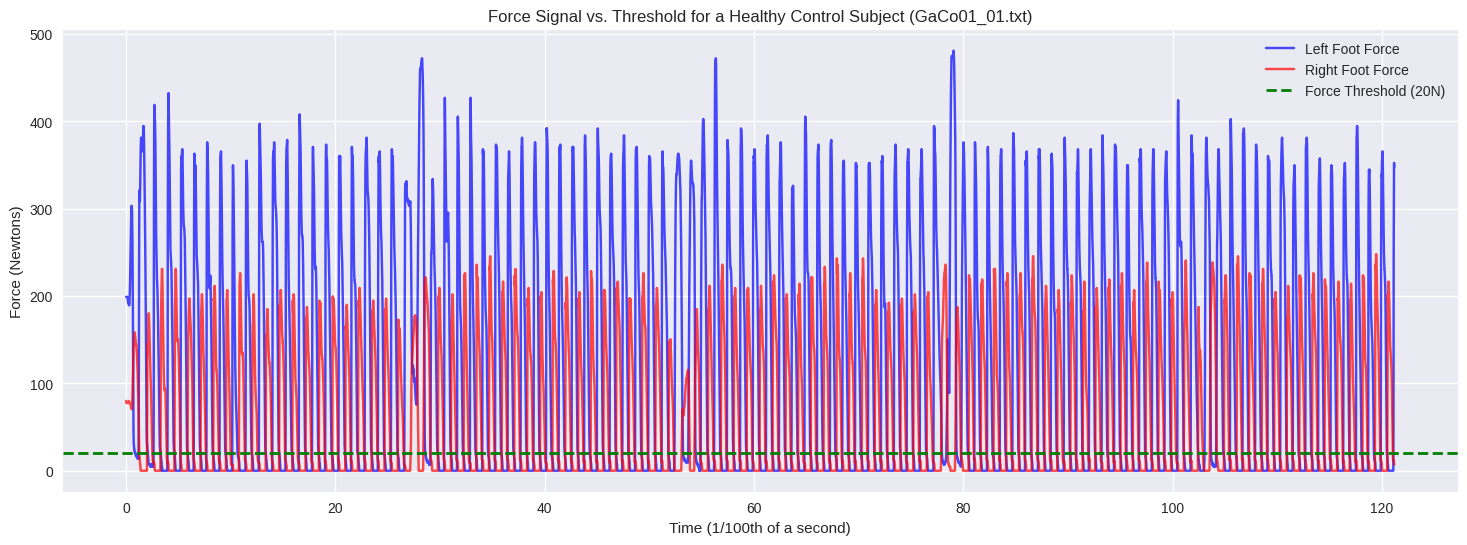

For the L foot, found 98 heel strikes crossing the 20N threshold.
For the R foot, found 97 heel strikes crossing the 20N threshold.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("--- Running Final Gait Diagnostic ---")

# The file we know should exist for a healthy control
control_file_path = 'GaCo01_01.txt'
force_threshold = 20 # The threshold we are testing

try:
    columns_gait = ['L_Total', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6', 'L7', 'L8', 'R_Total', 'R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8']
    data = pd.read_csv(control_file_path, sep='\t', header=None, names=columns_gait)

    print(f"Successfully loaded '{control_file_path}'.")

    # Plotting
    plt.figure(figsize=(18, 6))
    plt.plot(data.index, data['L_Total'], label='Left Foot Force', color='blue', alpha=0.7)
    plt.plot(data.index, data['R_Total'], label='Right Foot Force', color='red', alpha=0.7)

    # This is the most important part: draw our threshold line
    plt.axhline(y=force_threshold, color='green', linestyle='--', linewidth=2, label=f'Force Threshold ({force_threshold}N)')

    plt.title(f'Force Signal vs. Threshold for a Healthy Control Subject ({control_file_path})')
    plt.xlabel('Time (1/100th of a second)')
    plt.ylabel('Force (Newtons)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Diagnostic Calculation
    for foot in ['L', 'R']:
        force_signal = data[f'{foot}_Total'].values
        is_stance = force_signal > force_threshold
        stance_changes = np.diff(is_stance.astype(int))
        heel_strikes = np.where(stance_changes == 1)[0]
        print(f"For the {foot} foot, found {len(heel_strikes)} heel strikes crossing the {force_threshold}N threshold.")

except FileNotFoundError:
    print(f"\n[ERROR] The diagnostic file '{control_file_path}' was not found. Please ensure it is uploaded.")
except Exception as e:
    print(f"\nAn error occurred: {e}")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from tqdm.notebook import tqdm

# ======================================================================
# PHASE 1 - VOICE DATA (Correct)
# ======================================================================
print("--- Phase 1: Preprocessing Voice Data ---")
try:
    voice_column_names = ['subject_id'] + [f'feature_{i}' for i in range(1, 27)] + ['metadata_feature'] + ['class_label']
    df_voice_raw = pd.read_csv('train_data.txt', header=None, names=voice_column_names)
    df_voice_raw = df_voice_raw.drop(columns=['metadata_feature'])

    agg_cols = [col for col in df_voice_raw.columns if 'feature' in col]
    aggregation_rules = {col: 'mean' for col in agg_cols}
    aggregation_rules['class_label'] = 'first'
    subject_df = df_voice_raw.groupby('subject_id').agg(aggregation_rules).reset_index(drop=True)

    print(f"✅ Voice data correctly aggregated. Final Shape: {subject_df.shape}")
except Exception as e:
    print(f"Could not process voice data. Error: {e}")

# ======================================================================
# PHASE 1 - GAIT DATA (DEFINITIVE V3 Preprocessing)
# ======================================================================
print("\n--- Phase 1: Preprocessing Gait Data ---")
columns_gait = ['L_Total', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6', 'L7', 'L8', 'R_Total', 'R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8']

def extract_gait_features_definitive(file_path, force_threshold=5):
    try:
        data = pd.read_csv(file_path, sep='\t', header=None, names=columns_gait)
    except FileNotFoundError: return None

    features = {}
    for foot in ['L', 'R']:
        force_signal = data[f'{foot}_Total'].values
        is_stance = force_signal > force_threshold

        stance_changes = np.diff(is_stance.astype(int))
        heel_strikes = np.where(stance_changes == 1)[0]
        toe_offs = np.where(stance_changes == -1)[0]

        if len(heel_strikes) < 3 or len(toe_offs) < 3: continue

        if toe_offs[0] < heel_strikes[0]: toe_offs = toe_offs[1:]
        if len(toe_offs) == 0: continue
        if heel_strikes[-1] > toe_offs[-1]: heel_strikes = heel_strikes[:-1]
        if len(heel_strikes) == 0: continue

        min_len = min(len(heel_strikes), len(toe_offs))
        if min_len < 2: continue
        heel_strikes, toe_offs = heel_strikes[:min_len], toe_offs[:min_len]

        stride_times = np.diff(heel_strikes) / 100.0
        stance_times = (toe_offs - heel_strikes) / 100.0
        swing_times = (heel_strikes[1:] - toe_offs[:-1]) / 100.0

        if len(stride_times) > 1 and len(swing_times) > 1 and len(stance_times) > 1:
            features[f'{foot}_stride_time_mean'] = np.mean(stride_times)
            features[f'{foot}_stride_time_cv'] = (np.std(stride_times) / np.mean(stride_times)) * 100 if np.mean(stride_times) > 0 else 0
            features[f'{foot}_swing_time_mean'] = np.mean(swing_times)
            features[f'{foot}_swing_time_cv'] = (np.std(swing_times) / np.mean(swing_times)) * 100 if np.mean(swing_times) > 0 else 0
            features[f'{foot}_stance_time_mean'] = np.mean(stance_times)
            features[f'{foot}_stance_time_cv'] = (np.std(stance_times) / np.mean(stance_times)) * 100 if np.mean(stance_times) > 0 else 0

    return features

try:
    demographics_df = pd.read_excel('demographics.xls')
    id_col_name = demographics_df.columns[0]
    group_col_name = demographics_df.columns[1]

    all_subject_features = []
    for idx, row in tqdm(demographics_df.iterrows(), total=demographics_df.shape[0], desc="Processing Gait Files"):
        subject_id = str(row[id_col_name]).strip()
        trial_files = [f"{subject_id}_01.txt", f"{subject_id}_02.txt"]

        subject_trial_features = []
        for file in trial_files:
            features = extract_gait_features_definitive(file)
            if features: subject_trial_features.append(features)

        if not subject_trial_features: continue

        mean_features = pd.DataFrame(subject_trial_features).mean().to_dict()
        mean_features['class_label'] = 0 if row[group_col_name] == 1 else 1
        all_subject_features.append(mean_features)

    gait_features_df = pd.DataFrame(all_subject_features).dropna()
    print(f"\n✅ Gait data successfully processed. Final Shape: {gait_features_df.shape}")
    print("Class distribution in processed gait data:")
    print(gait_features_df['class_label'].value_counts())

except Exception as e:
    print(f"Could not process gait data. Error: {e}")

# ======================================================================
# PHASE 2 - ESTABLISH BASELINES
# ======================================================================
print("\n--- Phase 2: Establishing Baselines ---")
def train_and_evaluate(model, X_train, y_train, X_test, y_test, title, results_dict):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    accuracy = accuracy_score(y_test, preds)
    print(f"\n--- Results for: {title} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, preds, zero_division=0))
    results_dict[title] = accuracy

baseline_results = {}

# Voice-Only Model
if 'subject_df' in locals() and not subject_df.empty:
    X_voice = subject_df.drop(columns=['class_label'])
    y_voice = subject_df['class_label']
    X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(X_voice, y_voice, test_size=0.3, random_state=42, stratify=y_voice)
    scaler_v = StandardScaler().fit(X_train_v)
    train_and_evaluate(RandomForestClassifier(random_state=42), scaler_v.transform(X_train_v), y_train_v, scaler_v.transform(X_test_v), y_test_v, "Voice-Only Model", baseline_results)

# Gait-Only Model
if 'gait_features_df' in locals() and not gait_features_df.empty and gait_features_df['class_label'].nunique() > 1:
    X_gait = gait_features_df.drop(columns=['class_label'])
    y_gait = gait_features_df['class_label']
    X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(X_gait, y_gait, test_size=0.3, random_state=42, stratify=y_gait)
    scaler_g = StandardScaler().fit(X_train_g)
    train_and_evaluate(RandomForestClassifier(random_state=42), scaler_g.transform(X_train_g), y_train_g, scaler_g.transform(X_test_g), y_test_g, "Gait-Only Model", baseline_results)

    # Naive Fusion Model
    voice_pd = subject_df[subject_df['class_label'] == 1]
    voice_control = subject_df[subject_df['class_label'] == 0]
    gait_pd = gait_features_df[gait_features_df['class_label'] == 1]
    gait_control = gait_features_df[gait_features_df['class_label'] == 0]

    if not gait_pd.empty and not gait_control.empty:
        fused_pd = pd.concat([voice_pd.drop(columns=['class_label']).reset_index(drop=True), gait_pd.sample(n=len(voice_pd), random_state=42, replace=True).reset_index(drop=True)], axis=1)
        fused_pd['class_label'] = 1
        fused_control = pd.concat([voice_control.drop(columns=['class_label']).reset_index(drop=True), gait_control.sample(n=len(voice_control), random_state=42, replace=True).reset_index(drop=True)], axis=1)
        fused_control['class_label'] = 0
        fused_df = pd.concat([fused_pd, fused_control]).reset_index(drop=True)

        X_fused = fused_df.drop(columns=['class_label'])
        y_fused = fused_df['class_label']
        X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_fused, y_fused, test_size=0.3, random_state=42, stratify=y_fused)
        scaler_f = StandardScaler().fit(X_train_f)
        train_and_evaluate(RandomForestClassifier(random_state=42), scaler_f.transform(X_train_f), y_train_f, scaler_f.transform(X_test_f), y_test_f, "Naive Fusion Model", baseline_results)

# Final Summary
print("\n--- BASELINE SUMMARY ---")
if baseline_results:
    summary_df = pd.DataFrame.from_dict(baseline_results, orient='index', columns=['Accuracy'])
    print(summary_df.sort_values('Accuracy', ascending=False))
else:
    print("No baseline models were successfully trained.")
print("------------------------")

--- Phase 1: Preprocessing Voice Data ---
✅ Voice data correctly aggregated. Final Shape: (40, 27)

--- Phase 1: Preprocessing Gait Data ---


Processing Gait Files:   0%|          | 0/166 [00:00<?, ?it/s]


✅ Gait data successfully processed. Final Shape: (165, 13)
Class distribution in processed gait data:
class_label
1    165
Name: count, dtype: int64

--- Phase 2: Establishing Baselines ---

--- Results for: Voice-Only Model ---
Accuracy: 0.5000
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         6
           1       0.50      0.50      0.50         6

    accuracy                           0.50        12
   macro avg       0.50      0.50      0.50        12
weighted avg       0.50      0.50      0.50        12


--- BASELINE SUMMARY ---
                  Accuracy
Voice-Only Model       0.5
------------------------
